# Importamos las librerías

In [ ]:
!pip install tensorflow==2.9.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.7/511.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.7/438.7 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 50.6 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 24.3.25
    Uninstalling flatbuffers-24.3.25:
      Successfully uninstalled flatbuffers-24.3.25
  Attempting uninstall: tensorboard-data-serve

In [ ]:
# System Libs
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image
import zipfile
from google.colab import drive

# Data Handling Tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignorar Warnings
import warnings
warnings.filterwarnings("ignore")
print (' ')
print ('Los modulos fueron cargados exitosamente')

 
Los modulos fueron cargados exitosamente


# Extraigo las imágenes del zip para usarlas en Google Collab

In [ ]:
!rm -r /content/dataset/
drive.mount('/content/drive')
!ls "/content/drive/My Drive/Trabajo Final - Deep Learning/"

print (' ')
print ('Se conectó a Google Drive exitosamente')

rm: cannot remove '/content/dataset/': No such file or directory
Mounted at /content/drive
'Medicamentos_TP_Deep_Learning v4.zip'	'Presentación - TP Final - Deep Learning.pdf'
 medicamentovalidatorv2			'TP Final - Deep Learning'
'Modelo entrenado'			'Trabajo práctico final_ Deep Learning.pdf'
 
Se conectó a Google Drive exitosamente


In [ ]:
# Ruta al archivo zip en Google Drive
zip_path = '/content/drive/My Drive/Trabajo Final - Deep Learning/Medicamentos_TP_Deep_Learning_v4.zip'

# Extraer el contenido del zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

# Ruta del directorio extraído
data_dir = '/content/dataset'

print (' ')
print ('La ruta se generó exitosamente')

 
La ruta se generó exitosamente


In [ ]:
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

# Concateno los data paths con sus labels en un único dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis= 1)

In [ ]:
df

,filepaths,labels
0,/content/dataset/Fish Oil/00000434.jpg,Fish Oil
1,/content/dataset/Fish Oil/00000087.jpg,Fish Oil
2,/content/dataset/Fish Oil/00000566.jpg,Fish Oil
3,/content/dataset/Fish Oil/00000081.jpg,Fish Oil
4,/content/dataset/Fish Oil/00000334.jpg,Fish Oil
...,...,...
9995,/content/dataset/DayZinc/00000967.jpg,DayZinc
9996,/content/dataset/DayZinc/00000559.jpg,DayZinc
9997,/content/dataset/DayZinc/00000907.jpg,DayZinc
9998,/content/dataset/DayZinc/00000005.jpg,DayZinc


# Separo el dataframe en entrenamiento, validación y prueba

In [ ]:
# train dataframe
train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123)

# valid and test dataframe
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.6, shuffle= True, random_state= 123)

# Verifico las dimensiones de los conjuntos
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(valid_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 8000
Validation set size: 1200
Test set size: 800


In [ ]:
# Tamaño de la imagen recortada
batch_size = 64
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

# Función utilizada para data augmentation
def scalar(img):
    return img

tr_gen = ImageDataGenerator(preprocessing_function= scalar)
ts_gen = ImageDataGenerator(preprocessing_function= scalar)
train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)

Found 8000 validated image filenames belonging to 10 classes.
Found 1200 validated image filenames belonging to 10 classes.
Found 800 validated image filenames belonging to 10 classes.


# Muestra del set de entrenamiento

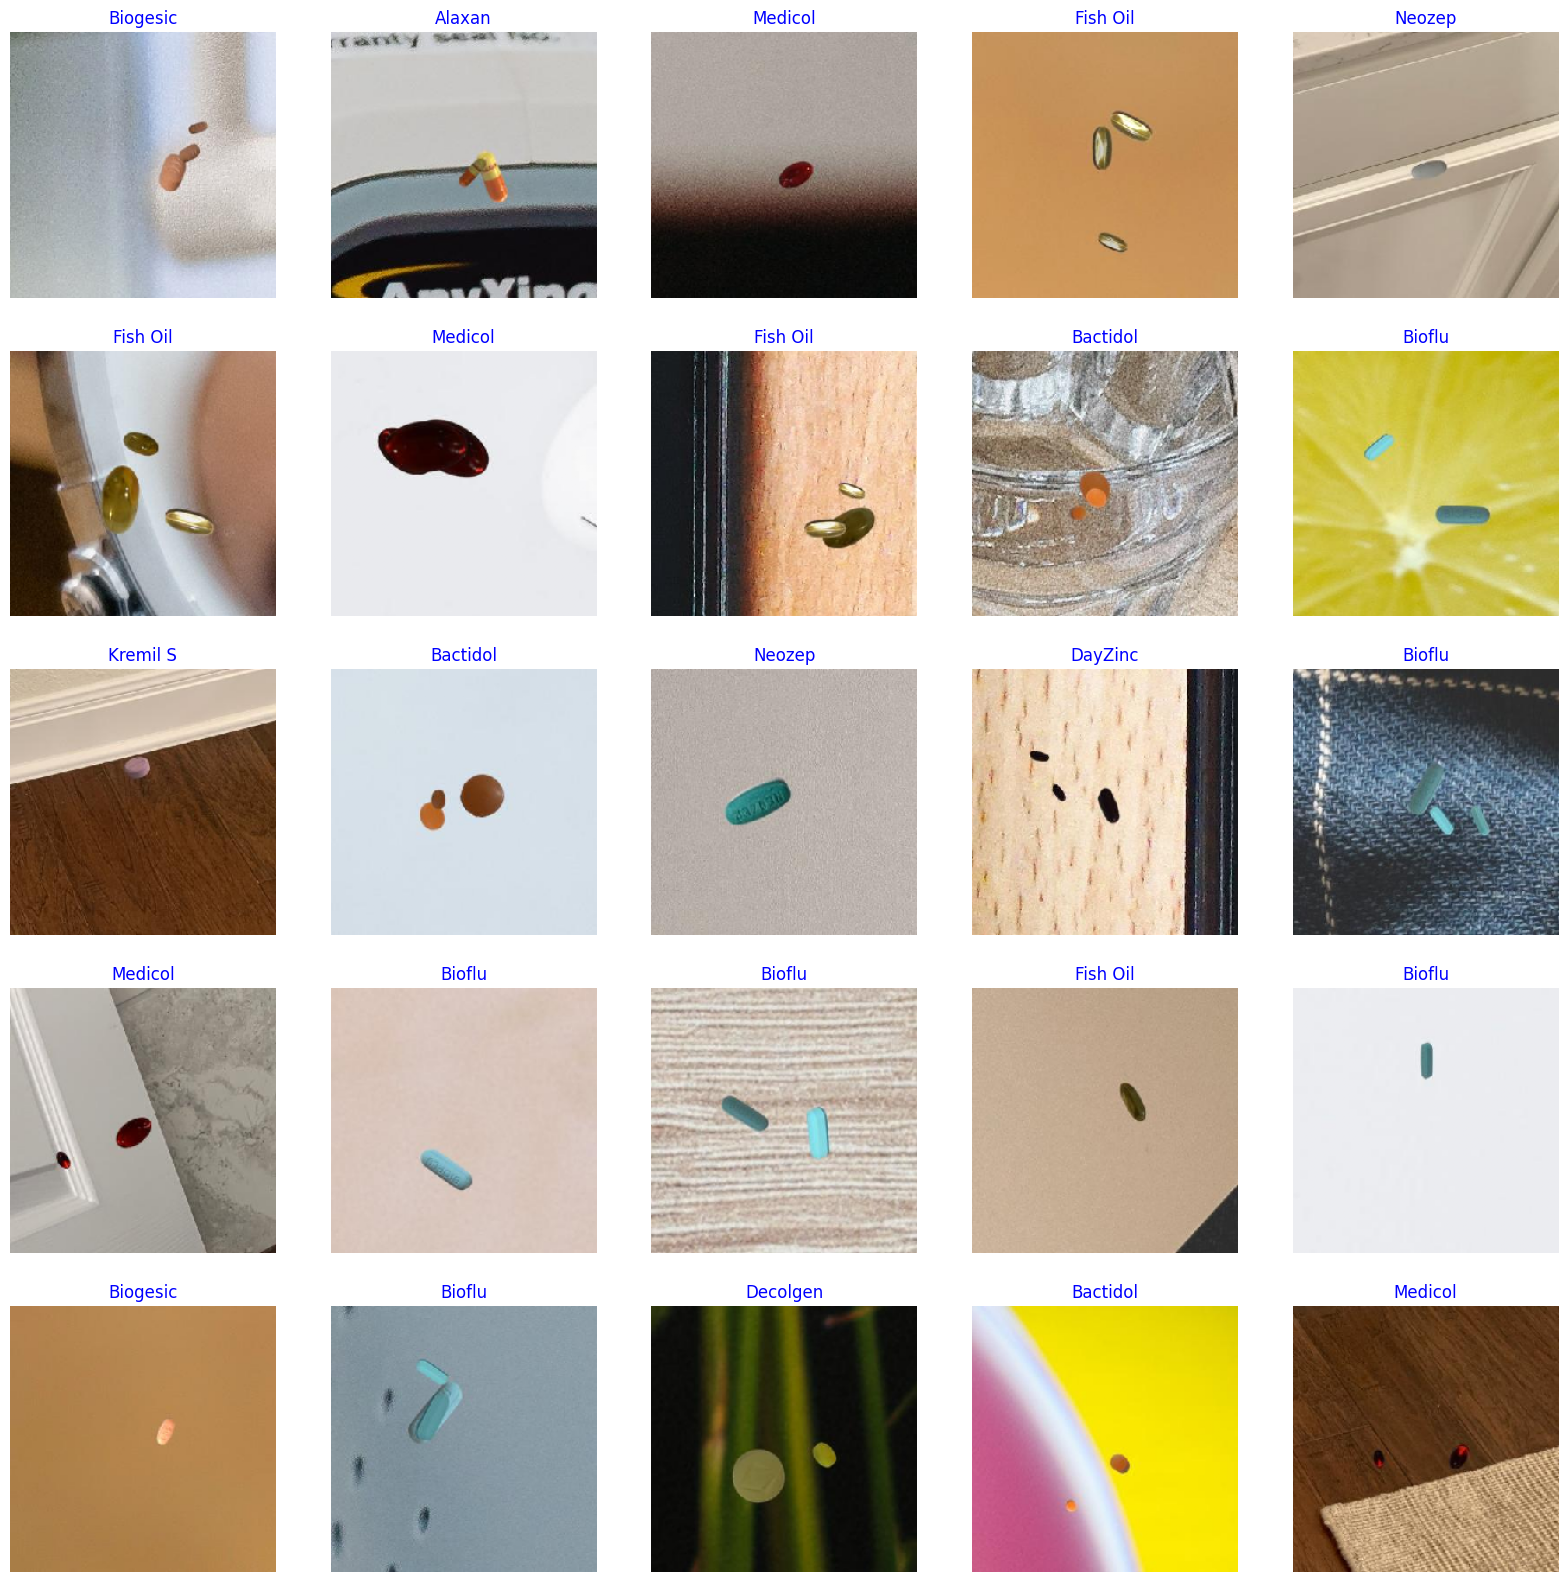

In [ ]:
g_dict = train_gen.class_indices
classes = list(g_dict.keys())
images, labels = next(train_gen)

# Número de muestras que vamos a mostrar
length = len(labels)
sample = min(length, 25)

plt.figure(figsize= (20, 20))
for i in range(sample):
    plt.subplot(5, 5, i + 1)
    image = images[i] / 255
    plt.imshow(image)
    class_index = np.argmax(labels[i])
    class_name = classes[class_index]
    plt.title(class_name, color= 'blue', fontsize= 12)
    plt.axis('off')
plt.show()

# Modelado

In [ ]:
# Creo la estructura del modelo
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

# Usamos el modeloo efficientnetb3 de la familia EfficientNet
base_model = tf.keras.applications.efficientnet.EfficientNetB1(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, kernel_regularizer= regularizers.l2(0.016), activity_regularizer= regularizers.l1(0.006),
                bias_regularizer= regularizers.l1(0.006), activation= 'relu'),
    Dropout(rate= 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

# Entrenamiento

In [ ]:
epochs = 3

history = model.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen,
                    validation_steps= None, shuffle= False)

Epoch 1/3
125/125 [==============================] - 3294s 26s/step - loss: 6.8690 - accuracy: 0.8267 - val_loss: 5.2279 - val_accuracy: 0.9817
Epoch 2/3
125/125 [==============================] - 3260s 26s/step - loss: 4.0788 - accuracy: 0.9854 - val_loss: 3.2259 - val_accuracy: 0.9933
Epoch 3/3
125/125 [==============================] - 3259s 26s/step - loss: 2.6008 - accuracy: 0.9939 - val_loss: 2.0375 - val_accuracy: 0.9967


In [ ]:
# Guardo el modelo
model.save('Drug_Name.h5')

# Performance del modelo

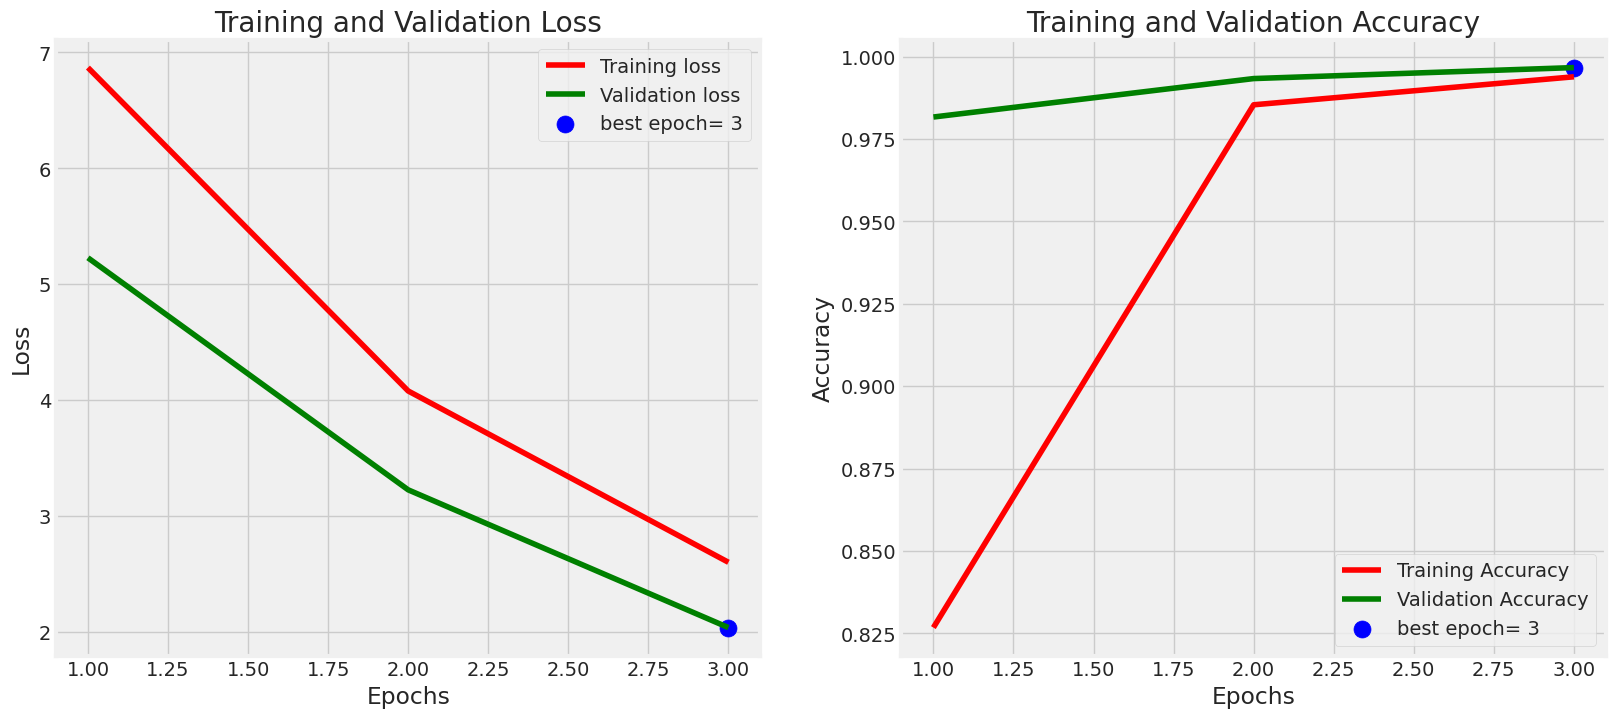

In [ ]:
# Defino las variables que necesito
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Grafico la historia del entrenamiento
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')
plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

# Prueba



In [ ]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)
print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

10/10 [==============================] - 79s 8s/step - loss: 2.0399 - accuracy: 0.9950
Train Loss:  2.025454044342041
Train Accuracy:  1.0
--------------------
Validation Loss:  2.03719162940979
Validation Accuracy:  0.996874988079071
--------------------
Test Loss:  2.0399417877197266
Test Accuracy:  0.9950000047683716


# Matriz de confusión y reporte de clasificación

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb1 (Functional)  (None, 1280)             6575239   
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 6,910,865
Trainable params: 6,846,250
Non-trainable params: 64,615
_________________________________________

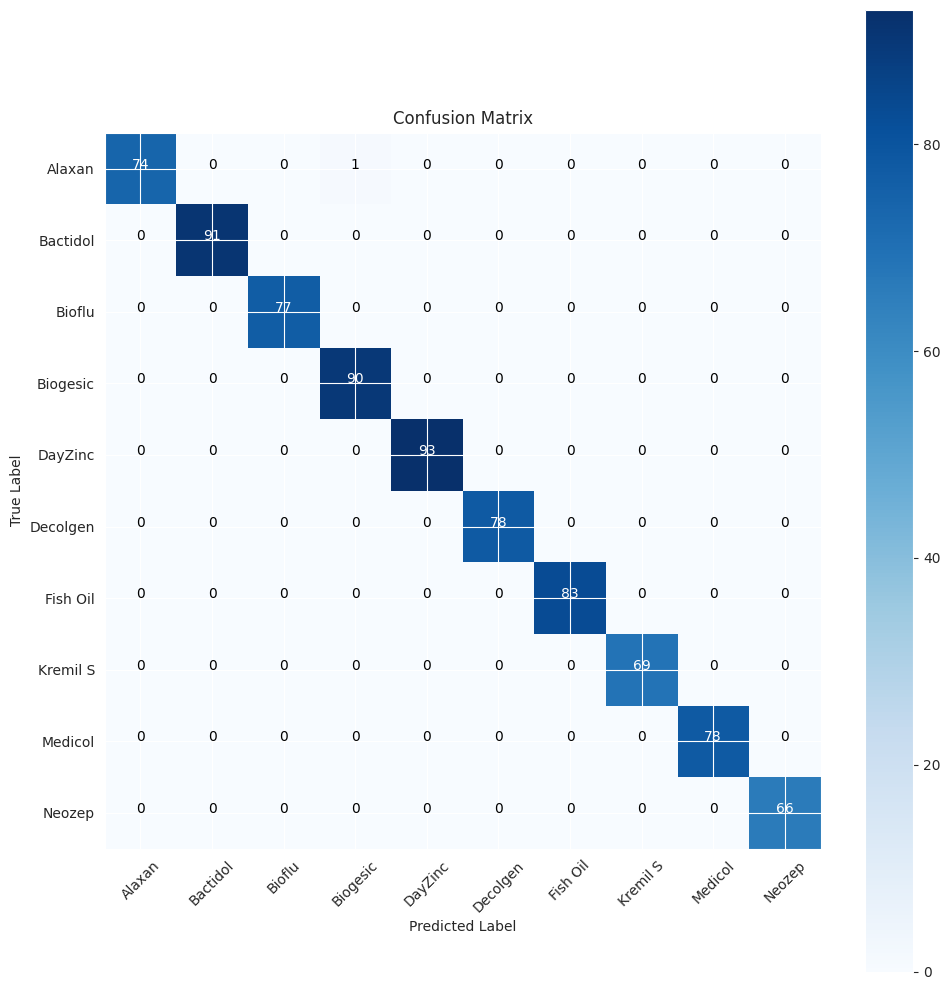

              precision    recall  f1-score   support

      Alaxan       1.00      0.99      0.99        75
    Bactidol       1.00      1.00      1.00        91
      Bioflu       1.00      1.00      1.00        77
    Biogesic       0.99      1.00      0.99        90
     DayZinc       1.00      1.00      1.00        93
    Decolgen       1.00      1.00      1.00        78
    Fish Oil       1.00      1.00      1.00        83
    Kremil S       1.00      1.00      1.00        69
     Medicol       1.00      1.00      1.00        78
      Neozep       1.00      1.00      1.00        66

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [ ]:
# Ruta al modelo guardado en Google Drive
model_path = '/content/drive/My Drive/Trabajo Final - Deep Learning/Modelo entrenado/Drug_Name.h5'

# Cargo el modelo
model = tf.keras.models.load_model(model_path)

# Verifico que el modelo se haya cargado correctamente
model.summary()

preds = model.predict_generator(test_gen)
y_pred = np.argmax(preds, axis=1)

g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Matriz de confusión
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

# Reporte de clasificación
print(classification_report(test_gen.classes, y_pred, target_names= classes))